In [161]:
from sklearn.datasets import make_regression
import numpy as np

In [162]:
x,y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

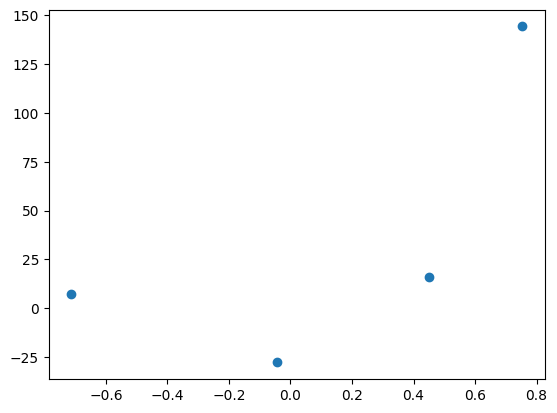

In [163]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

>let's apply OLS

In [164]:
from sklearn.linear_model import LinearRegression

In [165]:
reg =LinearRegression()
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [166]:
reg.coef_

array([78.35063668])

> what gradient descent do ? it randomly take any b value and at last it will end up at 26.15 . this is the goal of GD

In [167]:
reg.intercept_

np.float64(26.15963284313262)

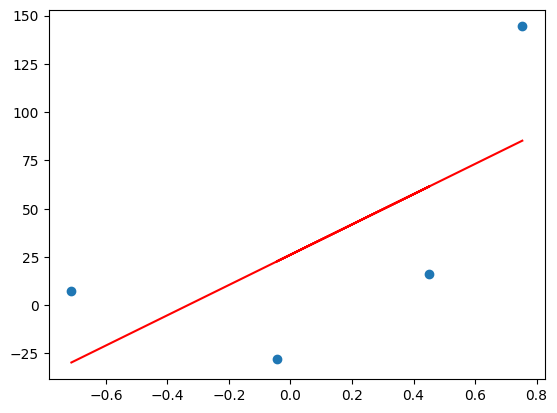

In [168]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color ='red')

>let's assume Gradient Descent slope is constant m=78.35
>and let's assume the starrting value for interceot b=0

In [169]:
y_pred = ((78.35*x)+0).reshape(4)# for all 4 value i am calculating the y pred value

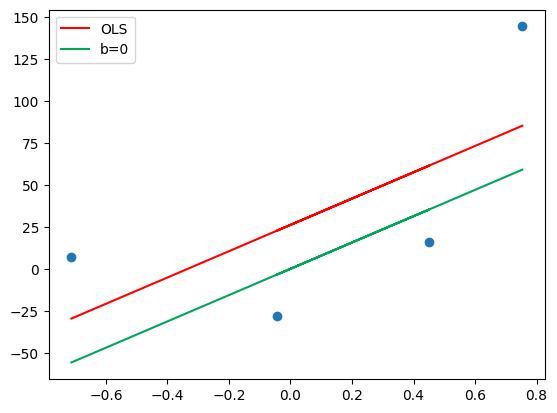

In [170]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='#00a65a',label='b=0')
plt.legend()
plt.show()

>at b=0

>iteration 1

In [171]:
m=78.35
b=0

los_slope = -2*np.sum(y-m*x.ravel()-b)
los_slope

np.float64(-209.27763408209216)

In [172]:
# let's learning rate =0.1
lr=0.1

step_size = los_slope*lr
step_size

np.float64(-20.927763408209216)

In [173]:
# calculateing the new intercept (bnew)
b= b- step_size
b

np.float64(20.927763408209216)

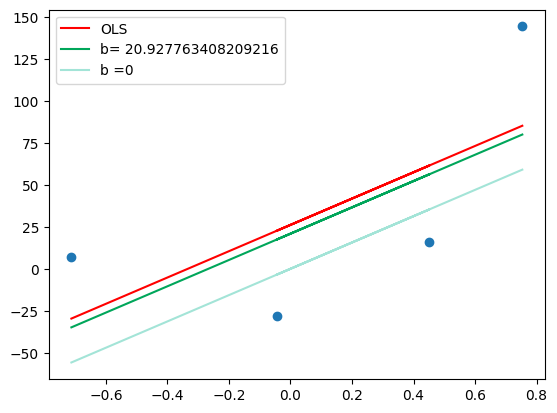

In [174]:
y_pred1 = ((78.35*x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color ='red',label ='OLS')
plt.plot(x,y_pred1,color ='#00a65a',label='b= {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b =0')
plt.legend()
plt.show()

>iteration 2

In [175]:
los_slope = -2*np.sum(y-m*x.ravel()-b)
los_slope

np.float64(-41.85552681641843)

In [176]:
step_size = los_slope*lr
step_size

np.float64(-4.185552681641844)

In [177]:
b=b-step_size
b

np.float64(25.11331608985106)

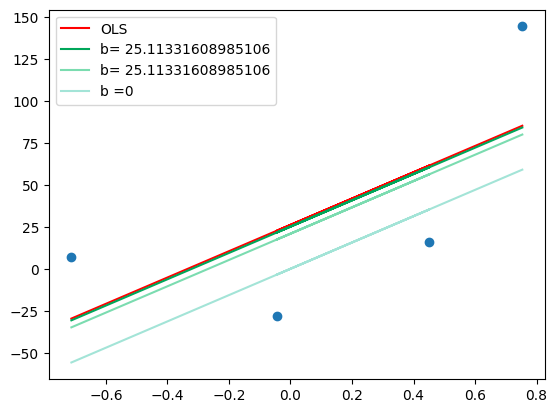

In [178]:
y_pred2 = ((78.35*x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color ='red',label ='OLS')
plt.plot(x,y_pred2,color ='#00a65a',label='b= {}'.format(b))
plt.plot(x,y_pred1,color ="#7BDCB0",label='b= {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b =0')
plt.legend()
plt.show()

>iteration 3

In [179]:
los_slope = -2*np.sum(y-m*x.ravel()-b)
los_slope

np.float64(-8.371105363283675)

In [180]:
step_size = los_slope*lr
step_size

np.float64(-0.8371105363283675)

In [181]:
b=b-step_size
b

np.float64(25.95042662617943)

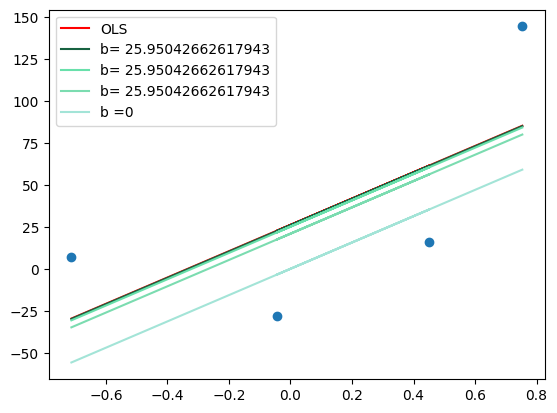

In [182]:
y_pred3 = ((78.35*x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color ='red',label ='OLS')
plt.plot(x,y_pred3,color ="#186241",label='b= {}'.format(b))
plt.plot(x,y_pred2,color ="#69e0ab",label='b= {}'.format(b))
plt.plot(x,y_pred1,color ="#7BDCB0",label='b= {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b =0')
plt.legend()
plt.show()

>iteration 4

In [183]:
los_slope = -2*np.sum(y-m*x.ravel()-b)
los_slope

np.float64(-1.674221072656735)

In [184]:
step_size = los_slope*lr
step_size

np.float64(-0.16742210726567353)

In [185]:
b=b-step_size
b

np.float64(26.1178487334451)

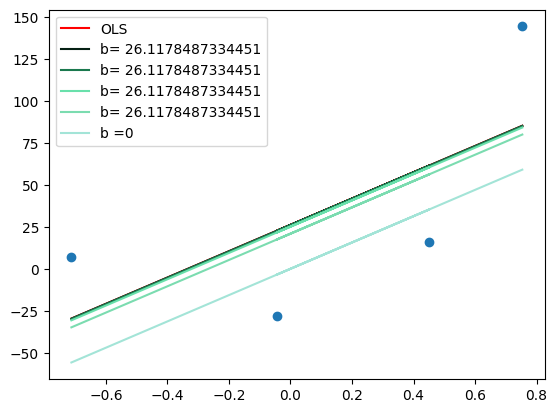

In [186]:
y_pred4 = ((78.35*x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color ='red',label ='OLS')
plt.plot(x,y_pred4,color ="#052014",label='b= {}'.format(b))
plt.plot(x,y_pred3,color ="#1A794E",label='b= {}'.format(b))
plt.plot(x,y_pred2,color ="#69e0ab",label='b= {}'.format(b))
plt.plot(x,y_pred1,color ="#7BDCB0",label='b= {}'.format(b))
plt.plot(x,y_pred,color='#A3E4D7',label='b =0')
plt.legend()
plt.show()

> using all these iteration in LOOP

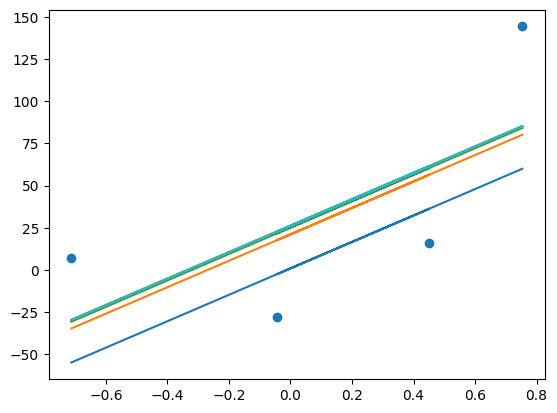

In [190]:
b =-100
m=78.35
lr =0.1 # if learning rate is small but need time 

epoch =10
 
for i in range(epoch):
    los_slope = -2*np.sum(y-m*x.ravel()-b)
    b=b-(lr*los_slope)

    y_pred = m*x +b
    plt.plot(x,y_pred)
plt.scatter(x,y)